# Customer Churn Prediction
## Deliverable P1: Exploratory Data Analysis & Preprocessing

**Dataset:** Telco Customer Churn (Kaggle)  
https://www.kaggle.com/datasets/blastchar/telco-customer-churn


## 1. Dataset Context

### Problem Description
Telco is a telecommunications company offering a wide range of services, including multiple lines, internet, online security, device protection, technical support, TV streaming, and movies, among others.

In recent years, the company has experienced a growing loss of customers (churn), which represents a direct and significant impact on revenue. To address this, Telco aims to develop a predictive solution that can identify in advance which customers are most likely to leave, enabling the implementation of targeted retention strategies.

### Dataset Source
- **Origin:** Kaggle — Telco Customer Churn
- **Size:** 7,043 customers and 21 columns
- **Each row:** a customer of a telecommunications company

The metadata contains the following:

- **Customers who left in the last month:** this column is called "Churn".
- **Services subscribed by each customer:** phone service, multiple lines, internet, online security, online backup, device protection, tech support, TV streaming, and movie streaming.
- **Customer account information:** tenure, contract type, payment method, paperless billing, monthly charges, and total charges.
- **Customer demographic information:** gender, age range, and whether they have a partner or dependents.

### Analysis Objective
Identify the profile of customers most at risk of churning, by studying the correlation between demographic variables, contracted services, and financial history. Based on these findings, the company can optimize its services and design retention strategies aimed at reducing the churn rate.


## 2. Data Loading & Initial Exploration


In [ ]:
# Import the libraries we'll use throughout the project
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### 2.2 Load the Dataset

I'm using `kagglehub` to pull the dataset directly from Kaggle, which keeps the notebook reproducible without needing to manually download any files.


In [ ]:
# Option 1: if you have the CSV downloaded locally
# df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [ ]:
# Option 2: load directly from Kaggle using kagglehub
# Install the library with pandas dataset support
!pip install kagglehub[pandas-datasets]

# Specific imports for loading
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Define the CSV file name we want to load
file_name = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load the dataset from Kaggle (blastchar/telco-customer-churn)
# directly into a pandas DataFrame called df.
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "blastchar/telco-customer-churn",
    file_name
)


Using Colab cache for faster access to the 'telco-customer-churn' dataset.


### 2.3 Dimensions and Data Types


In [ ]:
# Preview the first rows to get an idea of what the data looks like
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# And the last rows, to confirm there are no unusual values at the end of the file
df.tail()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
# Dataset structure: number of rows and columns
print(f'- The dataset contains {df.shape[0]} records with {df.shape[1]} columns.')


- El Dataset contiene 7043 registros con 21 columnas.


In [ ]:
# Data type per column
df.dtypes


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


### 2.4 Data Types & Initial Quality Check


In [ ]:
# General information: data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Two things stood out right away. `TotalCharges` is typed as object when it should be numeric, which usually means there are non-numeric values hiding somewhere. And `SeniorCitizen` is encoded as 0/1 while every other binary column uses Yes/No, so I'll standardize that too.


### 2.5 Descriptive Statistics


In [ ]:
# Numeric variables: mean, std, quartiles
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


A few things caught my attention here. The standard deviation for `tenure` is 25 with a mean of 32, which tells me the customer base is really spread out. You have people who just signed up sitting next to people who have been with the company for six years. There is no typical customer. For `MonthlyCharges`, the median is higher than the mean, which hints at a group pulling the average down, probably customers on basic plans. And `TotalCharges` has a standard deviation almost equal to its mean, so the distribution is heavily skewed by a small group of long-term customers racking up large totals.


In [ ]:
# Categorical variables: frequency, mode, unique values
df.describe(include=['object'])


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [ ]:
# Distribution of the Contract variable in percentages
df['Contract'].value_counts(normalize=True) * 100


,proportion
Contract,
Month-to-month,55.019168
Two year,24.066449
One year,20.914383


Over half the customer base is on a month-to-month plan. That is the least committed contract type, and as we will see later, also the one with the highest churn rate.


In [ ]:
# Absolute and relative frequency of the target variable (Churn)
print("Absolute frequency:")
print(df['Churn'].value_counts())
# We can see that 1869 out of 7043 customers churned

print("\nRelative Frequency (Percentages):")
percentage = df["Churn"].value_counts(normalize=True) * 100
print(round(percentage, 2))

print(f"\nApproximately 26.5% of the 7,043 customers have left the service")


Frecuencia absoluta:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Frecuencia Relativa (Porcentajes):
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Podemos visualizar que aprox el 26.5% de 7043 clientes se han retirado del servicio


In [ ]:
# Gender distribution — there is minimal imbalance between male and female customers
df['gender'].value_counts()


,count
gender,
Male,3555
Female,3488


Gender is almost perfectly balanced, only 67 customers separate the two groups. I will keep it in the analysis for now but I am not expecting it to matter much.


### 2.6 Summary: What Needs to Be Fixed

Before moving into the analysis I want to document everything that needs cleaning.

`customerID` is unique per row and has no predictive value, so it gets dropped. `TotalCharges` is stored as text and has hidden blank spaces that need to be converted to numeric. `SeniorCitizen` is encoded as 0/1 while everything else uses Yes/No, so I will standardize it. `Churn` is the target variable stored as Yes/No and needs to become binary 1/0 for modeling. And the column names mix camelCase with no separators, so I will standardize everything to snake_case.


### 2.7 Check for Null Values


In [ ]:
# Null count per column
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Search for hidden whitespace values (which pandas does NOT detect as NaN)
(df == ' ').sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


At first glance it looks like there are zero nulls, but that is misleading. Pandas only catches actual NaN values, not blank spaces. When I check for those manually I find 11 hidden empties in `TotalCharges` that need to be handled.


### 2.8 Check for Duplicates


In [ ]:
# Duplicate rows
df.duplicated().sum()


np.int64(0)

## 3. Data Preprocessing (Data Wrangling)


### 3.1 Drop `customerID`


In [ ]:
# Check how many unique values customerID has
df['customerID'].nunique()


7043

In [ ]:
# customerID is unique per row and carries no predictive value, so we drop it.
df = df.drop(columns=['customerID'])
df.shape  # check the shape after dropping


(7043, 20)

### 3.2 Convert `TotalCharges` to Numeric


In [ ]:
# Descriptive stats for TotalCharges (still as object)
df['TotalCharges'].describe()


,TotalCharges
count,7043
unique,6531
top,
freq,11


In [ ]:
# Count values disguised as whitespace
len(df[df['TotalCharges'] == " "])


11

In [ ]:
# Convert TotalCharges to numeric. Blank spaces become NaN.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Verify they were converted to NaN
print(f"Nulls in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# These correspond to customers with tenure=0 (haven't completed their first month),
# so TotalCharges should be 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Confirm the data type
print(df['TotalCharges'].dtype)


Nulos en TotalCharges: 11
float64


In [ ]:
# Verify that customers with tenure = 0
# haven't completed their first month, so TotalCharges should be 0

df[df['tenure'] == 0][['tenure', 'TotalCharges']]


,tenure,TotalCharges
488,0,0.0
753,0,0.0
936,0,0.0
1082,0,0.0
1340,0,0.0
3331,0,0.0
3826,0,0.0
4380,0,0.0
5218,0,0.0
6670,0,0.0


All 11 blank entries belong to customers with tenure equal to 0, meaning they had not completed their first billing cycle yet. Filling with 0 makes sense here since no charge was actually generated. Using the mean would be wrong.


### 3.3 Convert `SeniorCitizen` to Categorical


In [ ]:
# Convert SeniorCitizen from 0/1 to No/Yes
df['SeniorCitizen'] = np.where(df['SeniorCitizen'] == 1, 'Yes', 'No')
df['SeniorCitizen'].value_counts()


,count
SeniorCitizen,
No,5901
Yes,1142


### 3.4 Convert `Churn` to Binary Numeric


In [ ]:
# Convert Churn (target variable) to binary numeric:
#   "Yes" → 1 (customer left)
#   "No"  → 0 (customer stayed)
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Churn'].value_counts()


,count
Churn,
0,5174
1,1869


### 3.5 Standardize Column Names


In [ ]:
# Standardize column names to lowercase with no spaces
df.columns = df.columns.str.lower().str.replace(' ', '_')
print(df.columns.tolist())


['gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']


In [ ]:
# Rename only the columns whose meaning isn't immediately obvious.

df.rename(columns={
    'tenure'         : 'months_as_customer',
    'monthlycharges' : 'monthly_charges',
    'totalcharges'   : 'total_charges',
}, inplace=True)

print(df.columns.tolist())


['gender', 'seniorcitizen', 'partner', 'dependents', 'months_as_customer', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthly_charges', 'total_charges', 'churn']


## 3.6 Feature Engineering


In [ ]:
# 1. Tenure segment: group customers by how long they've been with the company
df['tenure_segment'] = pd.cut(df['months_as_customer'],
                               bins=[0, 12, 36, 72],
                               labels=['New', 'Mid', 'Loyal'],
                               include_lowest=True)
df['tenure_segment'].value_counts()


,count
segmento_antiguedad,
Leal,3001
Nuevo,2186
Medio,1856


I created three customer lifecycle stages based on how long someone has been with the company: New (0 to 12 months), Mid (13 to 36), and Loyal (37 to 72). This makes it easier to spot whether churn patterns change depending on where a customer is in their lifecycle.


In [ ]:
# 2. Total contracted services: count how many add-on services ("Yes") each customer has
services = ['onlinesecurity', 'onlinebackup', 'deviceprotection',
            'techsupport', 'streamingtv', 'streamingmovies']

df['total_services'] = (df[services] == 'Yes').sum(axis=1)
df['total_services'].value_counts().sort_index()


,count
total_servicios,
0,2219
1,966
2,1033
3,1118
4,852
5,571
6,284


The idea here is that a customer with 5 active services is much more embedded in the platform than someone on a basic plan. This variable collapses all those individual service columns into one engagement score.


In [ ]:
# 3. True monthly average: total charged divided by months as customer.
# Replace 0 with 1 to avoid division by zero (customers with tenure=0).
df['avg_monthly_charges'] = (df['total_charges'] / df['months_as_customer'].replace(0, 1)).round(2)
df['avg_monthly_charges'].describe()


,promedio_mensual_real
count,7043.000000
mean,64.698184
std,30.270690
min,0.000000
25%,35.650000
50%,70.300000
75%,90.170000
max,121.400000


This is different from `monthly_charges`, which only reflects the current plan price. `avg_monthly_charges` tells me what a customer actually paid on average across their whole relationship with the company, which can differ if they ever changed plans.


In [ ]:
# Final check: dataset structure ready for EDA
print("Final columns:")
print(df.columns.tolist())
print(f"\nShape: {df.shape}")
print(f"\nData types:")
print(df.dtypes)


Columnas finales:
['gender', 'seniorcitizen', 'partner', 'dependents', 'months_as_customer', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthly_charges', 'total_charges', 'churn', 'segmento_antiguedad', 'total_servicios', 'promedio_mensual_real']

Dimensiones: (7043, 23)

Tipos de datos:
gender                     object
seniorcitizen              object
partner                    object
dependents                 object
months_as_customer          int64
phoneservice               object
multiplelines              object
internetservice            object
onlinesecurity             object
onlinebackup               object
deviceprotection           object
techsupport                object
streamingtv                object
streamingmovies            object
contract                   object
paperlessbilling           object
payme

## 4. Exploratory Data Analysis (EDA)

Now that the data is clean I want to understand how each variable behaves on its own and how variables relate to each other, especially in relation to churn. I split this into univariate analysis first, then multivariate.


In [ ]:
# Global configuration so all EDA charts look consistent
sns.set_style("whitegrid")
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titleweight'] = 'bold'

# Variable lists we'll reuse throughout the EDA
num_vars = ['months_as_customer', 'monthly_charges', 'total_charges',
            'total_services', 'avg_monthly_charges']

cat_vars = ['gender', 'seniorcitizen', 'partner', 'dependents', 'phoneservice',
            'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup',
            'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies',
            'contract', 'paperlessbilling', 'paymentmethod', 'tenure_segment']

print(f"Numeric variables: {len(num_vars)}")
print(f"Categorical variables: {len(cat_vars)}")


Variables numéricas: 5
Variables categóricas: 17


### 4.1 Univariate Analysis


#### 4.1.1 Target Variable Distribution: `churn`


In [ ]:
# Absolute and relative frequency of churn
print("Absolute frequency:")
print(df['churn'].value_counts())
print()

print("\nRelative frequency (%):")
print(df['churn'].value_counts(normalize=True) * 100)
print()

print(f"\nApproximately 26.5% of the 7,043 customers have left the service")
print(round(percentage, 2))


Frecuencia absoluta:
churn
0    5174
1    1869
Name: count, dtype: int64


Frecuencia relativa (%):
churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


Podemos visualizar que aprox el 26.5% de 7043 clientes se han retirado del servicio
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


/tmp/ipykernel_2507/2464113173.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette='rainbow')


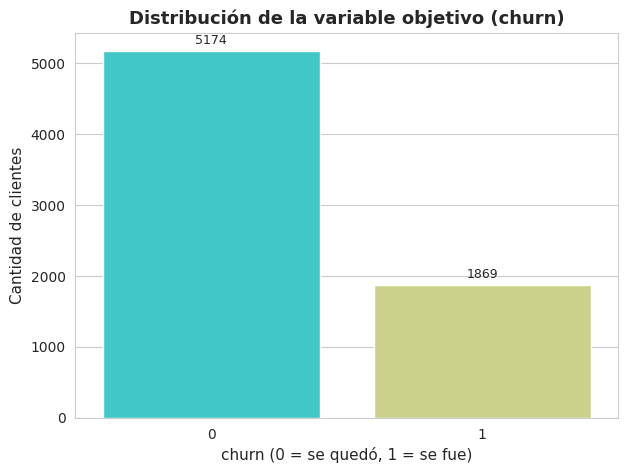

In [ ]:
# Target variable plot
plt.figure(figsize=(7, 5))
sns.countplot(x='churn', data=df, palette='rainbow')
plt.title('Target Variable Distribution (churn)')
plt.xlabel('churn (0 = stayed, 1 = churned)')
plt.ylabel('Number of customers')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


About 26.5% of customers churned, roughly one in four. That is a moderate class imbalance. It means that in P2 I cannot rely on accuracy as the main metric because a model that always predicts "stayed" would already score around 73% without learning anything. I will use F1-score and Recall instead since they actually measure how well the model catches churners.


#### 4.1.2 Descriptive Statistics for Numeric Variables (no charts)


In [ ]:
# Descriptive statistics for numeric variables
df[num_vars].describe()


,months_as_customer,monthly_charges,total_charges,total_servicios,promedio_mensual_real
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,2.037910,64.698184
std,24.559481,30.090047,2266.794470,1.847682,30.270690
min,0.000000,18.250000,0.000000,0.000000,0.000000
25%,9.000000,35.500000,398.550000,0.000000,35.650000
50%,29.000000,70.350000,1394.550000,2.000000,70.300000
75%,55.000000,89.850000,3786.600000,3.000000,90.170000
max,72.000000,118.750000,8684.800000,6.000000,121.400000


Looking at the descriptive stats for the numeric variables, a few things stand out.

`months_as_customer` has a standard deviation of 25 with a mean of 32. The dispersion is almost as large as the mean, which tells me the customer base is very heterogeneous. New customers and six-year veterans coexist in the same dataset.

`monthly_charges` has a median of 70.4 and a mean of 64.8. The median is higher, which points to a left skew. There is a group pulling the average down, likely customers on cheaper basic plans.

`total_charges` has a standard deviation almost equal to its mean. The distribution is very asymmetric, driven by a small group of long-tenured customers who have accumulated large totals over time.

`total_services` ranges from 0 to 6 with a mean of 2. Most customers subscribe to only a few add-ons. The maximum of 6 means some customers have everything.

`avg_monthly_charges` tracks closely with `monthly_charges` but sits slightly lower on average, which suggests that longer-tenured customers tend to be on older, cheaper plans.


#### 4.1.3 Distribution of Numeric Variables


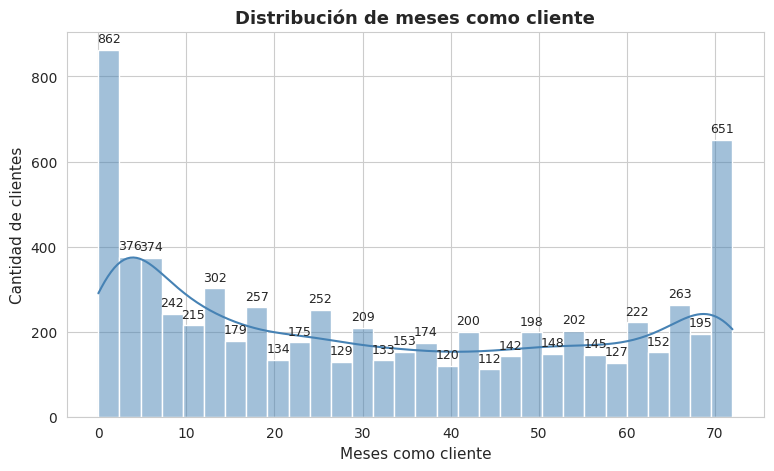

In [ ]:
# Histogram: months_as_customer (customer tenure)
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='months_as_customer', bins=30, kde=True, color='steelblue')
plt.title('Distribution of Months as Customer')
plt.xlabel('Months as Customer')
plt.ylabel('Number of Customers')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


`months_as_customer` shows a bimodal distribution with two clear peaks. One near the start representing newly acquired customers, and another near 70 months for long-term customers. This confirms what the statistics already suggested: two very different customer profiles coexist in this dataset.


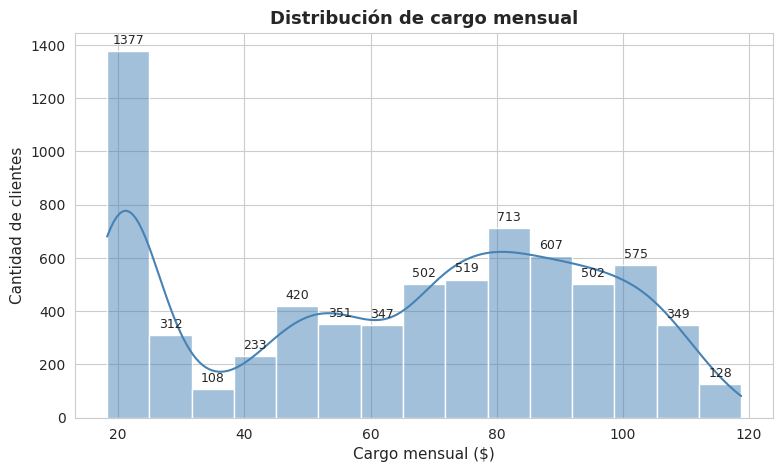

In [ ]:
# Histogram: monthly_charges
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='monthly_charges', bins=15, kde=True, color='steelblue')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


`monthly_charges` is also bimodal. There is a cluster near $20 which are likely basic plan customers, and a second cluster between $70 and $100 which corresponds to customers on full bundles. The gap between them is quite clear. The company basically operates across two distinct price segments.


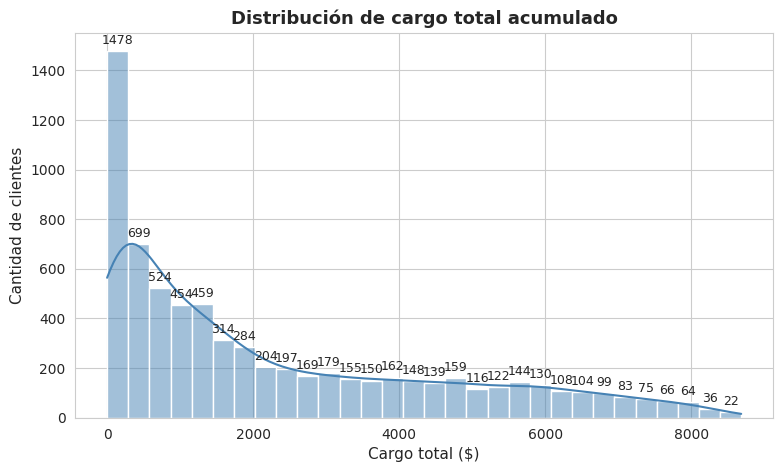

In [ ]:
# Histogram: total_charges (accumulated total)
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='total_charges', bins=30, kde=True, color='steelblue')
plt.title('Distribution of Total Charges (Accumulated)')
plt.xlabel('Total Charges ($)')
plt.ylabel('Number of Customers')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


`total_charges` is strongly right-skewed. Most customers have accumulated relatively little, while a small group of long-tenured customers has racked up very large totals. This is expected since total charges grow with time. If I end up using scale-sensitive models in P2 like Logistic Regression or SVM, I will likely apply a log transformation here.


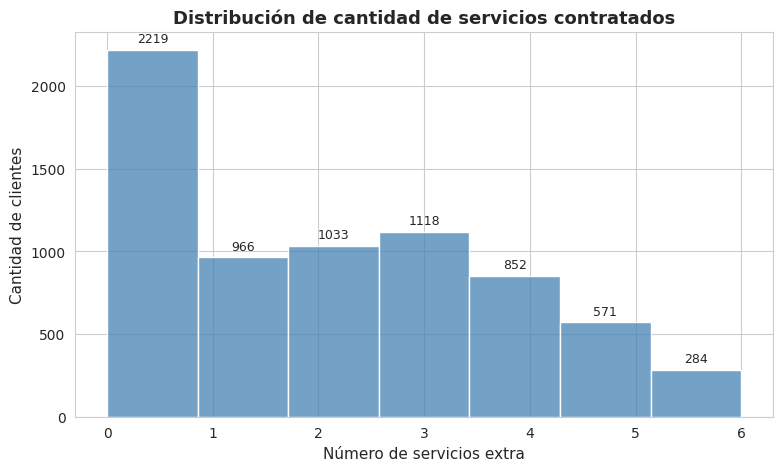

In [ ]:
# Histogram: total_services (number of add-on services)
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='total_services', bins=7, kde=False, color='steelblue')
plt.title('Distribution of Number of Contracted Services')
plt.xlabel('Number of Add-on Services')
plt.ylabel('Number of Customers')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


`total_services` is fairly spread across 0 to 6, with a slight concentration at the lower end. Most customers subscribe to just a few add-ons. The ones with 4 or more services are a minority, but as I will show in the multivariate section, they are also the least likely to churn.

I also checked all numeric variables for outliers. None of them have anomalies worth treating. The high values in `total_charges` look like outliers but they are just long-tenured customers who have naturally accumulated large totals over time.


#### 4.1.5 Categorical Variables — Composition


/tmp/ipykernel_2507/1810029286.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='contract', data=df, palette='viridis')


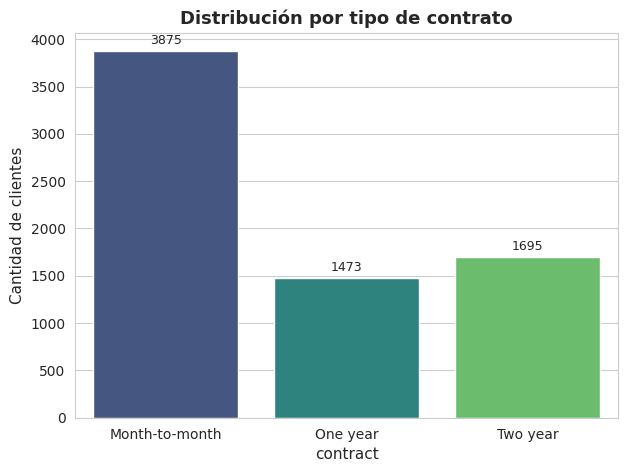

In [ ]:
# Countplot: contract type
plt.figure(figsize=(7, 5))
sns.countplot(x='contract', data=df, palette='viridis')
plt.title('Distribution by Contract Type')
plt.ylabel('Number of Customers')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


Month-to-month contracts dominate at around 55% of customers. That is important to keep in mind because this is also the contract type with the highest churn risk, so it will carry a lot of weight in the model.


/tmp/ipykernel_2507/3326745170.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='paymentmethod', data=df, palette='viridis')


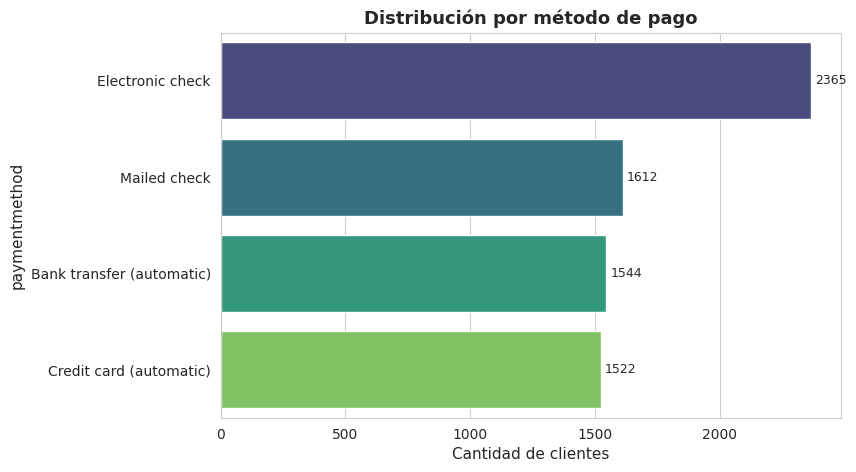

In [ ]:
# Countplot: payment method
plt.figure(figsize=(8, 5))
sns.countplot(y='paymentmethod', data=df, palette='viridis')
plt.title('Distribution by Payment Method')
plt.xlabel('Number of Customers')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


Electronic check is the most common payment method. What is interesting is that automatic payment methods like bank transfer and credit card require the customer to actively cancel to stop paying, which creates friction. Electronic check does not have that friction, which might partially explain why it correlates with higher churn.


/tmp/ipykernel_2507/3445426895.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='internetservice', data=df, palette='viridis')


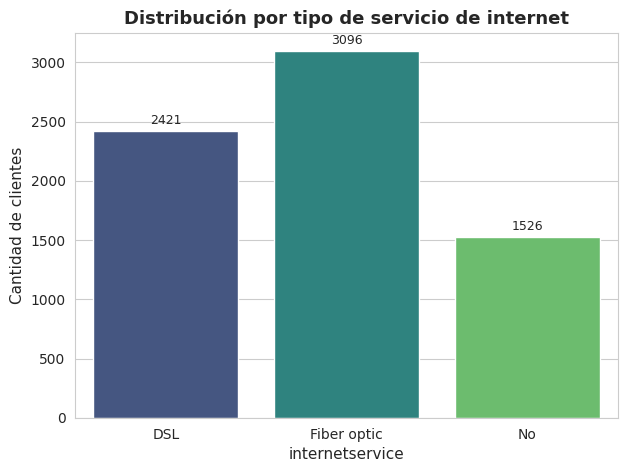

In [ ]:
# Countplot: internet service type
plt.figure(figsize=(7, 5))
sns.countplot(x='internetservice', data=df, palette='viridis')
plt.title('Distribution by Internet Service Type')
plt.ylabel('Number of Customers')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


Fiber optic is the largest internet service segment, followed by DSL. A portion of customers have no internet service at all through Telco. As I will show later, fiber optic customers churn at a much higher rate than DSL customers, which raises questions about pricing or service quality in that segment.


/tmp/ipykernel_2507/367316705.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='segmento_antiguedad', data=df, palette='viridis',


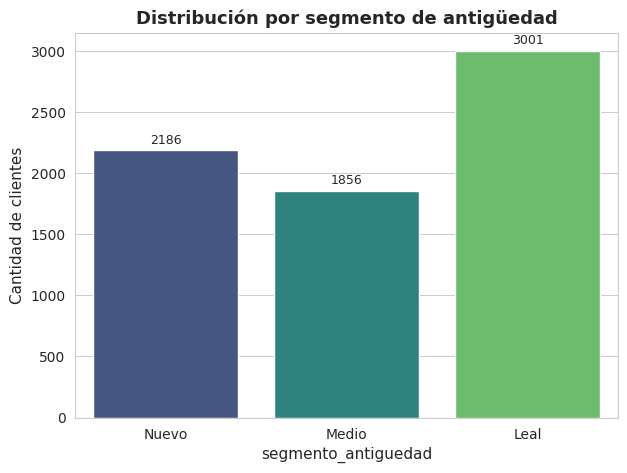

In [ ]:
# Countplot: tenure_segment (engineered feature)
plt.figure(figsize=(7, 5))
sns.countplot(x='tenure_segment', data=df, palette='viridis',
              order=['New', 'Mid', 'Loyal'])
plt.title('Distribution by Tenure Segment')
plt.ylabel('Number of Customers')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


The New and Loyal segments are the most numerous, with Mid being somewhat smaller. This reinforces the bimodal shape I saw in the tenure histogram. The first 12 months seem to be the critical window. If a customer gets through that period, the chances of them staying long-term go up significantly.


In [ ]:
# Frequencies for the main categorical variables
df['contract'].value_counts()


,count
contract,
Month-to-month,3875
Two year,1695
One year,1473


In [ ]:
df['paymentmethod'].value_counts()


,count
paymentmethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


In [ ]:
df['internetservice'].value_counts()


,count
internetservice,
Fiber optic,3096
DSL,2421
No,1526


### 4.2 Multivariate Analysis

Now I want to look at how variables relate to each other, and more importantly, how each one relates to churn. This is where the actual signals for the model start to appear.


#### 4.2.1 Correlations Between Numeric Variables


In [ ]:
# Covariance matrix (numeric variables)
df[num_vars].cov()


,months_as_customer,monthly_charges,total_charges,total_servicios,promedio_mensual_real
months_as_customer,603.168108,183.196987,4.599442e+04,22.428700,185.405308
monthly_charges,183.196987,905.410934,4.441523e+04,40.291356,905.705042
total_charges,45994.421944,44415.233678,5.138357e+06,3119.570156,44699.806605
total_servicios,22.428700,40.291356,3.119570e+03,3.413928,40.257841
promedio_mensual_real,185.405308,905.705042,4.469981e+04,40.257841,916.314675


In [ ]:
# Pearson correlation (measures linear relationships)
df[num_vars].corr()


,months_as_customer,monthly_charges,total_charges,total_servicios,promedio_mensual_real
months_as_customer,1.000000,0.247900,0.826178,0.494263,0.249391
monthly_charges,0.247900,1.000000,0.651174,0.724706,0.994355
total_charges,0.826178,0.651174,1.000000,0.744827,0.651435
total_servicios,0.494263,0.724706,0.744827,1.000000,0.719782
promedio_mensual_real,0.249391,0.994355,0.651435,0.719782,1.000000


In [ ]:
# Spearman correlation (rank-based, captures non-linearities)
df[num_vars].corr(method='spearman')


,months_as_customer,monthly_charges,total_charges,total_servicios,promedio_mensual_real
months_as_customer,1.000000,0.276417,0.889696,0.470536,0.276411
monthly_charges,0.276417,1.000000,0.638028,0.743557,0.990696
total_charges,0.889696,0.638028,1.000000,0.716412,0.638854
total_servicios,0.470536,0.743557,0.716412,1.000000,0.738724
promedio_mensual_real,0.276411,0.990696,0.638854,0.738724,1.000000


The strongest relationship in the data is between `months_as_customer` and `total_charges` at 0.83. That makes sense since total charges are basically tenure multiplied by monthly charge. There is also a strong relationship between `monthly_charges` and `total_services` at around 0.7, which is almost tautological since more services means higher monthly costs. For modeling, this multicollinearity matters. I will likely drop `total_charges` in P2 since it does not add much that `months_as_customer` and `monthly_charges` do not already capture. Comparing Pearson and Spearman gives very similar results, which tells me the relationships are mostly linear.


#### 4.2.2 Correlation Heatmap


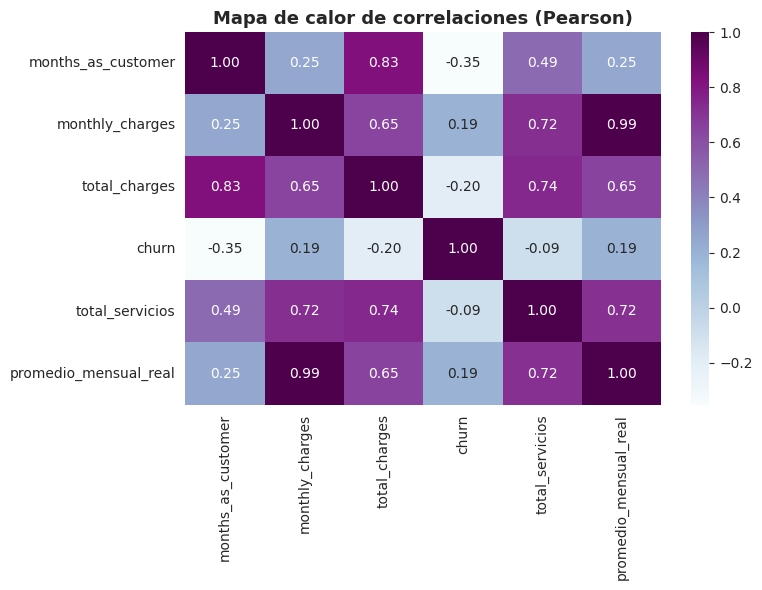

In [ ]:
# Heatmap of correlations for all numeric variables
plt.figure(figsize=(8, 6))
df_numeric = df.select_dtypes(include='number')
sns.heatmap(df_numeric.corr(), annot=True, cmap='BuPu', fmt='.2f')
plt.title('Correlation Heatmap (Pearson)')
plt.tight_layout()
plt.show()


The heatmap makes the multicollinearity visually obvious. The strong block between `months_as_customer` and `total_charges` stands out clearly. The other pairs are much weaker, which means the remaining variables are reasonably independent of each other.


### 4.2.3 Which Numeric Variables Are Most Associated with Churn?


#### 4.2.4 Numeric Variables vs Churn


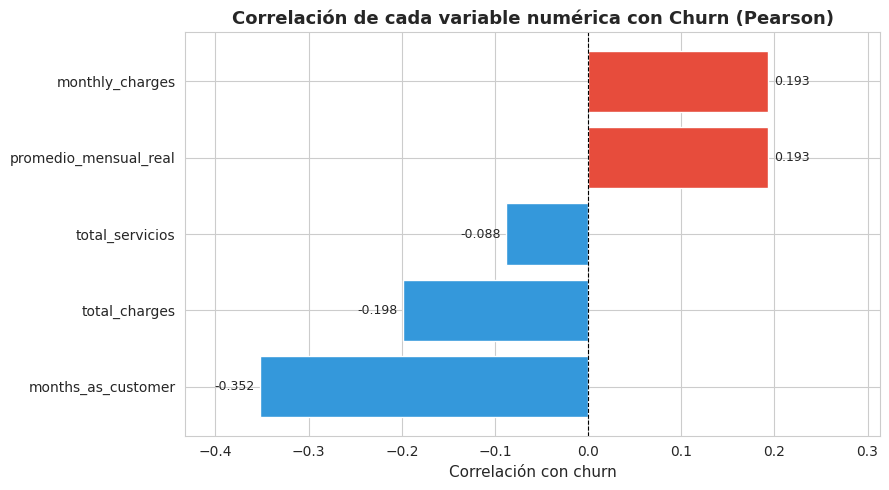

months_as_customer      -0.352229
total_charges           -0.198324
total_servicios         -0.087698
promedio_mensual_real    0.193300
monthly_charges          0.193356


In [ ]:
# Correlation of each numeric variable with churn (sorted)
corr_churn = (
    df.select_dtypes(include='number')
      .corr()['churn']
      .drop('churn')
      .sort_values()
)

# Visualization: horizontal bars colored by sign
plt.figure(figsize=(9, 5))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_churn.values]
bars = plt.barh(corr_churn.index, corr_churn.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
plt.title('Correlation of Each Numeric Variable with Churn (Pearson)')
plt.xlabel('Correlation with churn')
plt.xlim(corr_churn.min() - 0.08, corr_churn.max() + 0.12)
plt.tight_layout()
plt.show()

# Value table
print(corr_churn.to_string())


/tmp/ipykernel_2507/1449888553.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='months_as_customer', data=df, palette='rainbow')


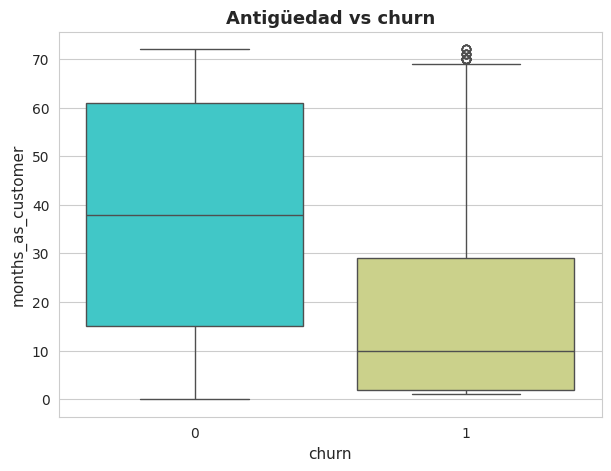

In [ ]:
# Boxplot: months_as_customer vs churn
plt.figure(figsize=(7, 5))
sns.boxplot(x='churn', y='months_as_customer', data=df, palette='rainbow')
plt.title('Customer Tenure vs Churn')
plt.show()


Looking at the correlations with `churn`, `months_as_customer` is the strongest signal at around -0.35. Customers who have been around longer churn less. `monthly_charges` is positively correlated at around 0.19, meaning customers paying more per month tend to churn more. This could point to a price-quality perception issue. `total_services` has a mild negative correlation, which supports the idea that more engagement leads to more retention. For categorical variables like `contract`, Pearson correlation does not capture the relationship well, which is why the crosstabs and grouped charts are more informative for those.


The difference here is really clear. Customers who stayed have a median tenure of around 38 months while churners have a median of only about 10 months. Churners are predominantly new customers. If someone makes it through the first year, the probability of them leaving drops significantly. This is probably the strongest single predictor in the dataset.


/tmp/ipykernel_2507/13996468.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='monthly_charges', data=df, palette='rainbow')


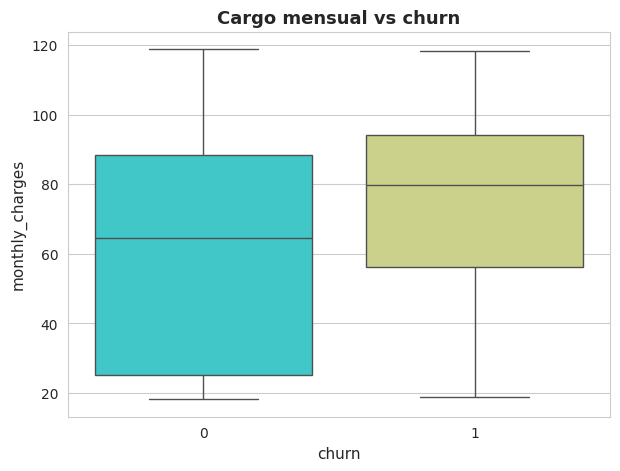

In [ ]:
# Boxplot: monthly_charges vs churn
plt.figure(figsize=(7, 5))
sns.boxplot(x='churn', y='monthly_charges', data=df, palette='rainbow')
plt.title('Monthly Charges vs Churn')
plt.show()


Customers who churned were paying more on average, around $80 per month versus $65 for those who stayed. That could mean customers on higher-priced plans are more price-sensitive and more likely to leave if they find a better deal elsewhere, or it could reflect real quality issues with the premium tier.


/tmp/ipykernel_2507/2973197531.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='total_servicios', data=df, palette='rainbow')


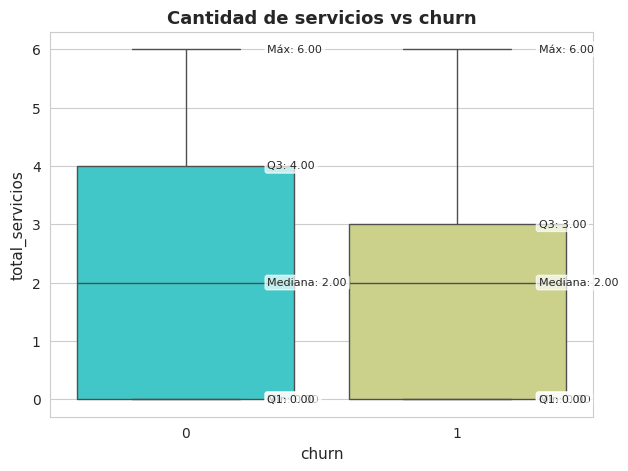

In [ ]:
# Boxplot: total_services vs churn
plt.figure(figsize=(7, 5))
sns.boxplot(x='churn', y='total_services', data=df, palette='rainbow')
plt.title('Number of Services vs Churn')
ax = plt.gca()

# Show exact statistic values per group
for i, group in enumerate(df['churn'].unique()):
    stats = df[df['churn'] == group]['total_services'].describe()
    values = {
        'Min':    stats['min'],
        'Q1':     stats['25%'],
        'Median': stats['50%'],
        'Q3':     stats['75%'],
        'Max':    stats['max']
    }
    for label, val in values.items():
        ax.text(i + 0.3, val, f'{label}: {val:.2f}',
                va='center', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
plt.show()


Customers who stayed have slightly more services on average. The more a customer is using, the more integrated they are with the company and the harder it is to leave. Someone with security, backup, tech support and streaming active has a lot more friction to overcome before canceling than someone on a basic plan.


#### 4.2.5 Categorical Variables vs Churn


In [ ]:
# Crosstab: Contract vs Churn (proportion within each contract type)
pd.crosstab(df['contract'], df['churn'], normalize='index') * 100


churn,0,1
contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


Contract type is the clearest split in the entire dataset. Month-to-month customers churn at around 43%, one-year contracts at 11%, and two-year contracts at just 3%. A month-to-month customer is 14 times more likely to churn than someone on a two-year contract. The retention implication is obvious: getting customers onto longer contracts is the single most effective lever.


In [ ]:
# Crosstab: InternetService vs Churn
pd.crosstab(df['internetservice'], df['churn'], normalize='index') * 100


churn,0,1
internetservice,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


Fiber optic customers churn at about 42%, DSL at 19%, and customers with no internet service at only 7%. My hypothesis is that fiber optic attracts more demanding customers who are actively comparing alternatives and have higher expectations for price and quality. It could also be pointing to real issues with the fiber product itself.


In [ ]:
# Crosstab: PaymentMethod vs Churn
pd.crosstab(df['paymentmethod'], df['churn'], normalize='index') * 100


churn,0,1
paymentmethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


Electronic check customers churn at about three times the rate of customers on automatic payment methods. Automatic payments create friction to cancel since you have to actively stop them. Electronic check has no such friction, so it is easier to just walk away.


### Demographic Variables vs Churn


#### SeniorCitizen vs Churn


churn             0     1
seniorcitizen            
No             76.4  23.6
Yes            58.3  41.7


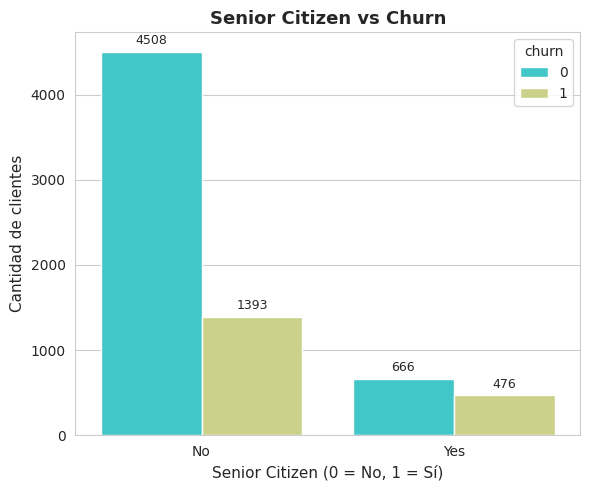

In [ ]:
# Crosstab: SeniorCitizen vs Churn
ct_senior = pd.crosstab(df['seniorcitizen'], df['churn'], normalize='index') * 100
print(ct_senior.round(1))

# Grouped countplot
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='seniorcitizen', data=df, hue='churn', palette='rainbow')
ax.set_title('Senior Citizen vs Churn')
ax.set_xlabel('Senior Citizen (No / Yes)')
ax.set_ylabel('Number of Customers')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.tight_layout()
plt.show()


Senior customers churn at 41% compared to 24% for non-seniors. They are only about 16% of the dataset but they are a notably high-risk segment.


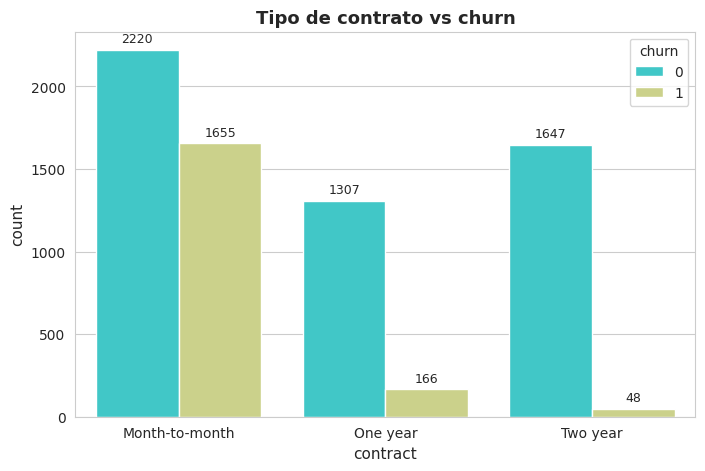

In [ ]:
# Grouped countplot: contract vs churn
plt.figure(figsize=(8, 5))
sns.countplot(x='contract', data=df, hue='churn', palette='rainbow')
plt.title('Contract Type vs Churn')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


The grouped bar chart makes the contract relationship very clear visually. As contract length increases, churn drops dramatically.


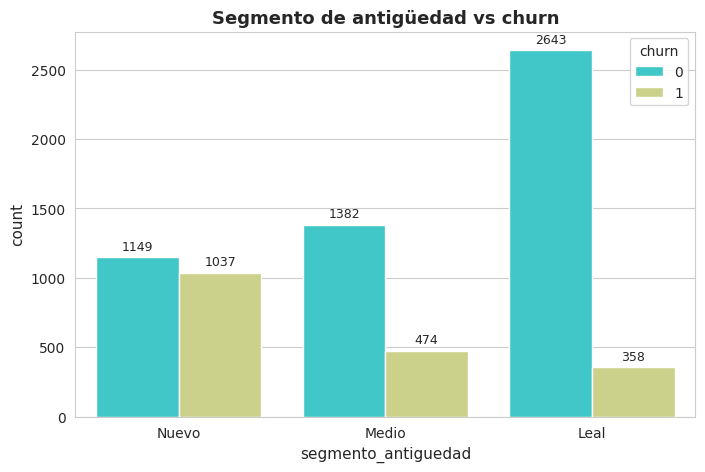

In [ ]:
# Grouped countplot: tenure_segment vs churn
plt.figure(figsize=(8, 5))
sns.countplot(x='tenure_segment', data=df, hue='churn',
              palette='rainbow', order=['New', 'Mid', 'Loyal'])
plt.title('Tenure Segment vs Churn')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


New customers (0 to 12 months) churn the most by far. Loyal customers (37 to 72 months) almost never leave. The lifecycle stage is one of the strongest signals in the data.


#### 4.2.7 Scatter Plots


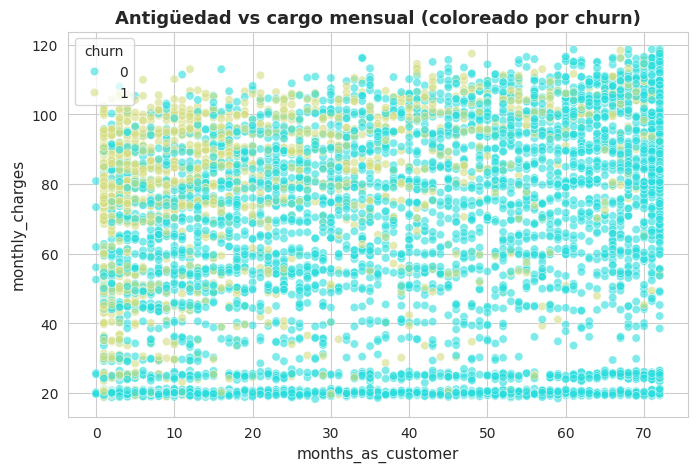

In [ ]:
# Scatterplot 1: months_as_customer vs monthly_charges
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='months_as_customer', y='monthly_charges',
                hue='churn', palette='rainbow', alpha=0.6)
plt.title('Customer Tenure vs Monthly Charges (colored by churn)')
plt.show()


Churners cluster in the upper left of this scatter plot, meaning short tenure combined with high monthly charges. That is the classic at-risk profile: a new customer who signed up for an expensive plan and then canceled.


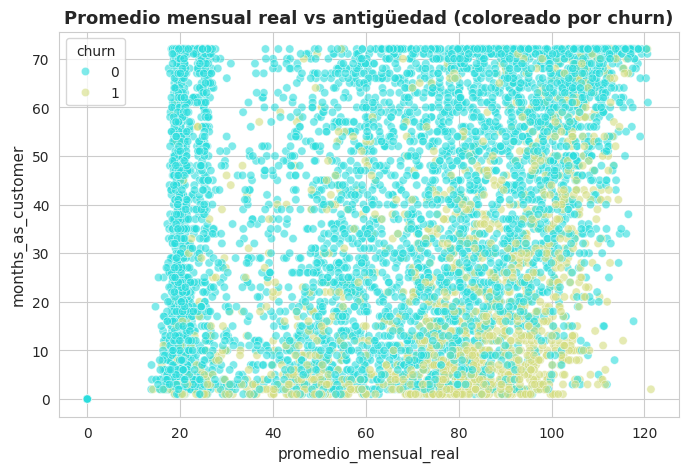

In [ ]:
# Scatterplot 6: avg_monthly_charges vs months_as_customer
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='avg_monthly_charges', y='months_as_customer',
                hue='churn', palette='rainbow', alpha=0.6)
plt.title('Average Monthly Charges vs Customer Tenure (colored by churn)')
plt.show()


New and long-tenured customers pay similar average monthly charges, which tells me there are no real loyalty discounts in this dataset. Churn concentrates in the low-tenure band regardless of how much a customer pays on average.


## 5. Key Findings

About 26.5% of customers churned, which is enough of an imbalance that accuracy alone is not a good metric for the model. In P2 I will focus on F1-score and Recall.

The single clearest driver of churn is contract type. A month-to-month customer is 14 times more likely to leave than someone on a two-year contract. On top of that, the first year is the most critical retention window. The median tenure for churners is only about 10 months.

Fiber optic and electronic check also concentrate high churn rates, which suggests issues with either price perception or service quality in those segments.

From a modeling perspective, `total_charges` will be dropped in P2 because it is too correlated with `months_as_customer` to add meaningful new information. The variables I expect to carry the most predictive weight are `contract`, `months_as_customer`, `internetservice`, and `paymentmethod`.
